# predic_consumo_agua_v8

Experimento complementario de validacion temporal para responder la observacion metodologica sobre la estructura de panel localidad-tiempo del conjunto de datos. Este notebook no reemplaza ni modifica los experimentos `predic_consumo_agua.ipynb` a `predic_consumo_agua_v7.ipynb`.

El objetivo es evaluar si el modelo XGBoost conserva capacidad predictiva cuando la particion respeta el orden cronologico de los datos. Se implementan una division temporal principal, una validacion de origen movil con ventana expansiva y una comparacion conceptual con la particion aleatoria y la validacion espacial Leave-One-Localidad-Out existentes.


## 1. Configuracion metodologica recuperada de los experimentos previos

La variable objetivo definitiva es `consumo_promedio`. Los experimentos previos entrenaron los modelos sobre `log1p(consumo_promedio)` y calcularon las metricas en la escala original mediante `expm1`. Las columnas `metros_cubicos`, `facturas`, `suscriptores_facturados` y `suscriptores_con_medidor` fueron excluidas por posible fuga de informacion, debido a su relacion operacional directa con el consumo promedio. Tambien se mantuvo la depuracion de variables climaticas redundantes o derivadas aplicada en v5-v7.

La configuracion XGBoost final de v5-v7 uso `XGBRegressor` con `objective='reg:squarederror'`, `n_estimators=400`, `learning_rate=0.05`, `max_depth=3`, `min_child_weight=3`, `subsample=0.8`, `colsample_bytree=0.8`, `reg_alpha=0.0`, `reg_lambda=1.0` y `random_state=42`. En este experimento temporal se usa 2023 como validacion para seleccionar hiperparametros sin consultar 2024. La validacion de origen movil usa una configuracion fija documentada para no seleccionar hiperparametros con los anos que funcionan como prueba.

La red neuronal profunda no se evalua en este notebook porque el entorno local no permite importar PyTorch por un error de carga de DLL (`c10.dll`). Para evitar resultados no reproducibles o reconstruidos manualmente, se documenta la limitacion tecnica y se concentra el experimento v8 en XGBoost, que es el modelo final analizado en v5-v7.


## 2. Importacion de librerias y versiones


In [1]:
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

import sklearn
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost
from xgboost import XGBRegressor

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

print("Version pandas:", pd.__version__)
print("Version numpy:", np.__version__)
print("Version scikit-learn:", sklearn.__version__)
print("Version XGBoost:", xgboost.__version__)

try:
    import torch
    TORCH_AVAILABLE = True
    TORCH_VERSION = torch.__version__
    TORCH_IMPORT_ERROR = ""
except Exception as exc:
    TORCH_AVAILABLE = False
    TORCH_VERSION = "no disponible"
    TORCH_IMPORT_ERROR = repr(exc)

print("Version PyTorch:", TORCH_VERSION)
if not TORCH_AVAILABLE:
    print("PyTorch no se evaluara por error tecnico:", TORCH_IMPORT_ERROR)


Version pandas: 2.3.3
Version numpy: 2.2.6
Version scikit-learn: 1.7.2
Version XGBoost: 2.1.4


Version PyTorch: 2.12.0+cpu


## 3. Carga, depuracion y preparacion de la base


In [2]:
DATA_PATH = Path("df_consumo_bime_clima_v3.xlsx")
TARGET = "consumo_promedio"
RANDOM_STATE = 42

LEAKAGE_COLUMNS = [
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",
]

REDUNDANT_OR_DERIVED_COLUMNS = [
    "T2MWET", "T2MDEW", "T2M_RANGE",
    "WS10M_MAX", "WS10M_MIN", "WS10M_RANGE",
    "WS2M_MAX", "WS2M_MIN", "WS2M_RANGE",
    "WD10M", "WD2M",
    "ALLSKY_SFC_PAR_TOT", "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA", "ALLSKY_SFC_UVB", "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN", "TOA_SW_DWN",
]

# Configuracion final usada en v5-v7. Se mantiene como referencia y para la validacion movil.
XGB_V5_FINAL_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Malla heredada de v5 para seleccionar configuracion con validacion temporal 2023.
XGB_TEMPORAL_PARAM_GRID = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

df_raw = pd.read_excel(DATA_PATH)
YEAR_COL = next(c for c in df_raw.columns if c.encode("unicode_escape").decode("ascii") == "a\\xf1o")
BIMESTER_COL = "BIMESTRE"
LOCALITY_COL = "localidad"

df_raw = df_raw.copy()
df_raw["_row_id"] = np.arange(len(df_raw))
df_raw[YEAR_COL] = pd.to_numeric(df_raw[YEAR_COL], errors="coerce")
df_raw[BIMESTER_COL] = pd.to_numeric(df_raw[BIMESTER_COL], errors="coerce")
df_raw = df_raw.sort_values([YEAR_COL, BIMESTER_COL, LOCALITY_COL]).reset_index(drop=True)

print("Dataset cargado:", DATA_PATH)
print("Dimensiones:", df_raw.shape)
print("Columna temporal detectada:", YEAR_COL)
print("Unidad de analisis duplicada localidad-ano-bimestre:", int(df_raw.duplicated([LOCALITY_COL, YEAR_COL, BIMESTER_COL]).sum()))
print("\nRegistros por ano:")
display(df_raw.groupby(YEAR_COL).size().rename("n_registros").reset_index())
print("\nRegistros por ano y bimestre:")
display(df_raw.groupby([YEAR_COL, BIMESTER_COL]).size().rename("n_registros").reset_index())


Dataset cargado: df_consumo_bime_clima_v3.xlsx
Dimensiones: (596, 50)
Columna temporal detectada: año
Unidad de analisis duplicada localidad-ano-bimestre: 0

Registros por ano:


,año,n_registros
0,2020,120
1,2021,120
2,2022,119
3,2023,120
4,2024,117



Registros por ano y bimestre:


,año,BIMESTRE,n_registros
0,2020,1,20
1,2020,2,20
2,2020,3,20
3,2020,4,20
4,2020,5,20
5,2020,6,20
6,2021,1,20
7,2021,2,20
8,2021,3,20
9,2021,4,20


In [3]:
def metrics_original_scale(y_true_log, y_pred_log):
    y_true = np.expm1(np.asarray(y_true_log, dtype=float))
    y_pred = np.expm1(np.asarray(y_pred_log, dtype=float))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def build_design_matrix(raw_df, include_spatial=True):
    data = raw_df.copy()
    if TARGET not in data.columns:
        raise ValueError(f"No existe la variable objetivo {TARGET!r}.")

    data = data[data[TARGET].notna()].copy()
    y = pd.to_numeric(data[TARGET], errors="coerce")
    valid_y = y.notna()
    data = data.loc[valid_y].copy()
    y = y.loc[valid_y]
    if (y < 0).any():
        raise ValueError("No se puede aplicar log1p porque existen valores negativos en el target.")

    metadata = data[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL]].copy()

    columns_to_drop = [c for c in LEAKAGE_COLUMNS + REDUNDANT_OR_DERIVED_COLUMNS if c in data.columns]
    columns_to_drop.append(TARGET)
    columns_to_drop.append(LOCALITY_COL)
    columns_to_drop.append("_row_id")
    if not include_spatial:
        columns_to_drop.extend([c for c in ["latitud", "longitud"] if c in data.columns])
    columns_to_drop = list(dict.fromkeys([c for c in columns_to_drop if c in data.columns]))

    X = data.drop(columns=columns_to_drop).copy()
    if BIMESTER_COL in X.columns:
        X[BIMESTER_COL] = pd.to_numeric(X[BIMESTER_COL], errors="coerce")
        X["BIMESTRE_sin"] = np.sin(2 * np.pi * X[BIMESTER_COL] / 6)
        X["BIMESTRE_cos"] = np.cos(2 * np.pi * X[BIMESTER_COL] / 6)
        X = X.drop(columns=[BIMESTER_COL])

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    return X.reset_index(drop=True), np.log1p(y).reset_index(drop=True), metadata.reset_index(drop=True), columns_to_drop


def make_xgb_model(params):
    return XGBRegressor(**params)


def impute_from_train(X_train, *other_splits):
    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    outputs = [X_train_imp]
    for split in other_splits:
        outputs.append(pd.DataFrame(imputer.transform(split), columns=X_train.columns, index=split.index))
    return outputs, imputer


def param_product(param_grid):
    import itertools
    keys = list(param_grid.keys())
    for values in itertools.product(*(param_grid[k] for k in keys)):
        params = dict(zip(keys, values))
        params.update({
            "reg_alpha": 0.0,
            "reg_lambda": 1.0,
            "objective": "reg:squarederror",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        })
        yield params


def year_label(years):
    years = sorted(set(int(y) for y in years))
    if not years:
        return ""
    if len(years) > 1 and years == list(range(min(years), max(years) + 1)):
        return f"{min(years)}-{max(years)}"
    return ",".join(str(y) for y in years)


## 4. Verificaciones contra fuga de informacion temporal


In [4]:
X_check, y_check, meta_check, dropped_columns_check = build_design_matrix(df_raw, include_spatial=True)

masks_main = {
    "entrenamiento_2020_2022": meta_check[YEAR_COL].between(2020, 2022),
    "validacion_2023": meta_check[YEAR_COL].eq(2023),
    "prueba_2024": meta_check[YEAR_COL].eq(2024),
}

assert meta_check.loc[masks_main["entrenamiento_2020_2022"], YEAR_COL].max() < meta_check.loc[masks_main["validacion_2023"], YEAR_COL].min()
assert meta_check.loc[masks_main["validacion_2023"], YEAR_COL].max() < meta_check.loc[masks_main["prueba_2024"], YEAR_COL].min()

row_sets = {name: set(meta_check.loc[mask, "_row_id"]) for name, mask in masks_main.items()}
for name_a, ids_a in row_sets.items():
    for name_b, ids_b in row_sets.items():
        if name_a < name_b:
            assert ids_a.isdisjoint(ids_b), f"Hay filas compartidas entre {name_a} y {name_b}"

print("Verificaciones cronologicas superadas:")
print(" - max(ano_train) < min(ano_val)")
print(" - max(ano_val) < min(ano_test)")
print(" - no existen _row_id compartidos entre conjuntos")

resumen_conjuntos = []
for conjunto, mask in masks_main.items():
    subset = meta_check.loc[mask]
    resumen_conjuntos.append({
        "conjunto": conjunto,
        "n_registros": len(subset),
        "anos": year_label(subset[YEAR_COL]),
        "localidades": subset[LOCALITY_COL].nunique(),
        "bimestres": ",".join(map(str, sorted(subset[BIMESTER_COL].dropna().astype(int).unique()))),
    })
resumen_conjuntos = pd.DataFrame(resumen_conjuntos)
display(resumen_conjuntos)

conteo_ano_conjunto = []
conteo_localidad_conjunto = []
for conjunto, mask in masks_main.items():
    subset = meta_check.loc[mask]
    c_year = subset.groupby(YEAR_COL).size().rename("n_registros").reset_index()
    c_year["conjunto"] = conjunto
    conteo_ano_conjunto.append(c_year)
    c_loc = subset.groupby([LOCALITY_COL, YEAR_COL]).size().rename("n_registros").reset_index()
    c_loc["conjunto"] = conjunto
    conteo_localidad_conjunto.append(c_loc)

conteo_ano_conjunto = pd.concat(conteo_ano_conjunto, ignore_index=True)
conteo_localidad_conjunto = pd.concat(conteo_localidad_conjunto, ignore_index=True)
print("Conteo exacto por ano y conjunto:")
display(conteo_ano_conjunto)
print("Conteo exacto por localidad, ano y conjunto:")
display(conteo_localidad_conjunto)

print("Columnas eliminadas:")
for col in dropped_columns_check:
    print(" -", col)
print("\nVariables predictoras con coordenadas:", X_check.columns.tolist())
print("Numero de variables predictoras con coordenadas:", X_check.shape[1])


Verificaciones cronologicas superadas:
 - max(ano_train) < min(ano_val)
 - max(ano_val) < min(ano_test)
 - no existen _row_id compartidos entre conjuntos


,conjunto,n_registros,anos,localidades,bimestres
0,entrenamiento_2020_2022,359,2020-2022,20,"1,2,3,4,5,6"
1,validacion_2023,120,2023,20,"1,2,3,4,5,6"
2,prueba_2024,117,2024,20,"1,2,3,4,5,6"


Conteo exacto por ano y conjunto:


,año,n_registros,conjunto
0,2020,120,entrenamiento_2020_2022
1,2021,120,entrenamiento_2020_2022
2,2022,119,entrenamiento_2020_2022
3,2023,120,validacion_2023
4,2024,117,prueba_2024


Conteo exacto por localidad, ano y conjunto:


,localidad,año,n_registros,conjunto
0,ANTONIO NARINO,2020,6,entrenamiento_2020_2022
1,ANTONIO NARINO,2021,6,entrenamiento_2020_2022
2,ANTONIO NARINO,2022,6,entrenamiento_2020_2022
3,BARRIOS UNIDOS,2020,6,entrenamiento_2020_2022
4,BARRIOS UNIDOS,2021,6,entrenamiento_2020_2022
...,...,...,...,...
95,SUMAPAZ,2024,3,prueba_2024
96,TEUSAQUILLO,2024,6,prueba_2024
97,TUNJUELITO,2024,6,prueba_2024
98,USAQUEN,2024,6,prueba_2024


Columnas eliminadas:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN
 - consumo_promedio
 - localidad
 - _row_id

Variables predictoras con coordenadas: ['año', 'latitud', 'longitud', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SRF_ALB', 'CLOUD_AMT', 'GWETPROF', 'GWETROOT', 'GWETTOP', 'ONI', 'PRECTOTCORR', 'PRECTOTCORR_SUM', 'PS', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'WS10M', 'WS2M', 'BIMESTRE_sin', 'BIMESTRE_cos']
Numero de variables predictoras con coordenadas: 24


## 5. Variables climaticas contemporaneas


In [5]:
feature_cols_with_spatial = X_check.columns.tolist()
non_climate_cols = {YEAR_COL, "latitud", "longitud", "BIMESTRE_sin", "BIMESTRE_cos"}
climate_like_cols = [c for c in feature_cols_with_spatial if c not in non_climate_cols]
lag_like_cols = [c for c in climate_like_cols if any(token in c.lower() for token in ["lag", "rezago", "prev", "forecast", "pred"])]

print("Variables climaticas/ambientales usadas en la matriz predictora:")
print(climate_like_cols)
print("Variables con nombre que sugiera rezago o pronostico:", lag_like_cols)
print(
    "Nota metodologica: la base contiene las variables climaticas en la misma fila ano-bimestre-localidad del target. "
    "Al no existir sufijos de rezago o pronostico en estos nombres, este experimento se interpreta como estimacion temporal "
    "con covariables contemporaneas conocidas, no como pronostico anticipado antes de observar el clima del bimestre objetivo."
)


Variables climaticas/ambientales usadas en la matriz predictora:
['ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SRF_ALB', 'CLOUD_AMT', 'GWETPROF', 'GWETROOT', 'GWETTOP', 'ONI', 'PRECTOTCORR', 'PRECTOTCORR_SUM', 'PS', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'WS10M', 'WS2M']
Variables con nombre que sugiera rezago o pronostico: []
Nota metodologica: la base contiene las variables climaticas en la misma fila ano-bimestre-localidad del target. Al no existir sufijos de rezago o pronostico en estos nombres, este experimento se interpreta como estimacion temporal con covariables contemporaneas conocidas, no como pronostico anticipado antes de observar el clima del bimestre objetivo.


## 6. Division temporal principal y seleccion con validacion 2023


In [6]:
def tune_xgb_on_2023(include_spatial):
    model_label = "XGBoost_con_latitud_longitud" if include_spatial else "XGBoost_sin_latitud_longitud"
    X, y_log, meta, dropped = build_design_matrix(df_raw, include_spatial=include_spatial)
    train_mask = meta[YEAR_COL].between(2020, 2022)
    val_mask = meta[YEAR_COL].eq(2023)
    test_mask = meta[YEAR_COL].eq(2024)

    X_train_raw, X_val_raw = X.loc[train_mask].copy(), X.loc[val_mask].copy()
    y_train, y_val = y_log.loc[train_mask].copy(), y_log.loc[val_mask].copy()
    (X_train, X_val), imputer = impute_from_train(X_train_raw, X_val_raw)

    tuning_rows = []
    for i, params in enumerate(param_product(XGB_TEMPORAL_PARAM_GRID), start=1):
        model = make_xgb_model(params)
        model.fit(X_train, y_train.values, verbose=False)
        pred_train = model.predict(X_train)
        pred_val = model.predict(X_val)
        train_metrics = metrics_original_scale(y_train, pred_train)
        val_metrics = metrics_original_scale(y_val, pred_val)
        tuning_rows.append({
            "modelo": model_label,
            "iteracion": i,
            **{k: params[k] for k in ["n_estimators", "learning_rate", "max_depth", "min_child_weight", "subsample", "colsample_bytree"]},
            "MAE_train": train_metrics["MAE"],
            "RMSE_train": train_metrics["RMSE"],
            "R2_train": train_metrics["R2"],
            "MAE_val_2023": val_metrics["MAE"],
            "RMSE_val_2023": val_metrics["RMSE"],
            "R2_val_2023": val_metrics["R2"],
        })

    tuning_df = pd.DataFrame(tuning_rows).sort_values(["RMSE_val_2023", "MAE_val_2023"], ascending=[True, True]).reset_index(drop=True)
    best_row = tuning_df.iloc[0]
    selected_params = {
        "n_estimators": int(best_row["n_estimators"]),
        "learning_rate": float(best_row["learning_rate"]),
        "max_depth": int(best_row["max_depth"]),
        "min_child_weight": int(best_row["min_child_weight"]),
        "subsample": float(best_row["subsample"]),
        "colsample_bytree": float(best_row["colsample_bytree"]),
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    # Modelo de seleccion: entrenado solo con 2020-2022 y evaluado en 2023.
    selection_model = make_xgb_model(selected_params)
    selection_model.fit(X_train, y_train.values, verbose=False)
    selection_rows = []
    for conjunto, X_split, y_split, years in [
        ("entrenamiento_2020_2022", X_train, y_train, [2020, 2021, 2022]),
        ("validacion_2023", X_val, y_val, [2023]),
    ]:
        pred = selection_model.predict(X_split)
        selection_rows.append({
            "modelo": model_label,
            "etapa": "seleccion_temporal",
            "conjunto": conjunto,
            "anos": year_label(years),
            "n_registros": len(y_split),
            "n_features": X.shape[1],
            "hiperparametros": json.dumps(selected_params, sort_keys=True),
            **metrics_original_scale(y_split, pred),
        })

    # Modelo final: una vez seleccionada la configuracion con 2023, se reentrena con 2020-2023 y se evalua una sola vez en 2024.
    final_train_mask = meta[YEAR_COL].between(2020, 2023)
    X_final_train_raw, X_test_raw = X.loc[final_train_mask].copy(), X.loc[test_mask].copy()
    y_final_train, y_test = y_log.loc[final_train_mask].copy(), y_log.loc[test_mask].copy()
    (X_final_train, X_test), final_imputer = impute_from_train(X_final_train_raw, X_test_raw)
    final_model = make_xgb_model(selected_params)
    final_model.fit(X_final_train, y_final_train.values, verbose=False)

    final_rows = []
    preds_2024 = None
    for conjunto, X_split, y_split, years in [
        ("entrenamiento_2020_2023", X_final_train, y_final_train, [2020, 2021, 2022, 2023]),
        ("prueba_2024", X_test, y_test, [2024]),
    ]:
        pred = final_model.predict(X_split)
        final_rows.append({
            "modelo": model_label,
            "etapa": "modelo_final",
            "conjunto": conjunto,
            "anos": year_label(years),
            "n_registros": len(y_split),
            "n_features": X.shape[1],
            "hiperparametros": json.dumps(selected_params, sort_keys=True),
            **metrics_original_scale(y_split, pred),
        })
        if conjunto == "prueba_2024":
            meta_test = meta.loc[test_mask].reset_index(drop=True)
            y_real = np.expm1(y_test.reset_index(drop=True))
            y_pred = np.expm1(pred)
            preds_2024 = pd.DataFrame({
                "localidad": meta_test[LOCALITY_COL],
                "ano": meta_test[YEAR_COL].astype(int),
                "bimestre": meta_test[BIMESTER_COL].astype(int),
                "valor_real": y_real,
                "prediccion": y_pred,
                "error": y_real - y_pred,
                "error_absoluto": np.abs(y_real - y_pred),
                "modelo": model_label,
            })

    return {
        "modelo": model_label,
        "include_spatial": include_spatial,
        "features": X.columns.tolist(),
        "tuning": tuning_df,
        "selected_params": selected_params,
        "metrics": pd.DataFrame(selection_rows + final_rows),
        "predictions_2024": preds_2024,
    }


temporal_results = [
    tune_xgb_on_2023(include_spatial=True),
    tune_xgb_on_2023(include_spatial=False),
]

resultados_tuning_temporal = pd.concat([r["tuning"] for r in temporal_results], ignore_index=True)
resultados_tuning_temporal.to_csv("resultados_tuning_temporal_xgboost_v8.csv", index=False, encoding="utf-8-sig")

resultados_validacion_temporal = pd.concat([r["metrics"] for r in temporal_results], ignore_index=True)
resultados_validacion_temporal.to_csv("resultados_validacion_temporal_v8.csv", index=False, encoding="utf-8-sig")

predicciones_temporales_2024 = pd.concat([r["predictions_2024"] for r in temporal_results], ignore_index=True)
predicciones_temporales_2024.to_csv("predicciones_temporales_2024_v8.csv", index=False, encoding="utf-8-sig")

selected_params_df = pd.DataFrame([
    {"modelo": r["modelo"], **{k: v for k, v in r["selected_params"].items() if k != "n_jobs"}}
    for r in temporal_results
])

print("Hiperparametros seleccionados usando exclusivamente validacion 2023:")
display(selected_params_df)
print("Resultados de la division temporal principal:")
display(resultados_validacion_temporal)
print("Primeras predicciones 2024:")
display(predicciones_temporales_2024.head(12))


Hiperparametros seleccionados usando exclusivamente validacion 2023:


,modelo,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,objective,random_state
0,XGBoost_con_latitud_longitud,200,0.05,4,1,0.8,0.8,0.0,1.0,reg:squarederror,42
1,XGBoost_sin_latitud_longitud,200,0.03,4,1,0.8,0.8,0.0,1.0,reg:squarederror,42


Resultados de la division temporal principal:


,modelo,etapa,conjunto,anos,n_registros,n_features,hiperparametros,MAE,RMSE,R2
0,XGBoost_con_latitud_longitud,seleccion_temporal,entrenamiento_2020_2022,2020-2022,359,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.188575,0.270429,0.993510
1,XGBoost_con_latitud_longitud,seleccion_temporal,validacion_2023,2023,120,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.876440,2.399930,-0.102191
2,XGBoost_con_latitud_longitud,modelo_final,entrenamiento_2020_2023,2020-2023,479,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.211024,0.325896,0.989150
3,XGBoost_con_latitud_longitud,modelo_final,prueba_2024,2024,117,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.121197,2.000640,0.293491
4,XGBoost_sin_latitud_longitud,seleccion_temporal,entrenamiento_2020_2022,2020-2022,359,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.338758,1.973403,0.654420
5,XGBoost_sin_latitud_longitud,seleccion_temporal,validacion_2023,2023,120,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",2.058024,3.145631,-0.893544
6,XGBoost_sin_latitud_longitud,modelo_final,entrenamiento_2020_2023,2020-2023,479,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.374674,2.031718,0.578292
7,XGBoost_sin_latitud_longitud,modelo_final,prueba_2024,2024,117,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.931455,2.443260,-0.053704


Primeras predicciones 2024:


,localidad,ano,bimestre,valor_real,prediccion,error,error_absoluto,modelo
0,ANTONIO NARINO,2024,1,11.036871,11.109701,-0.072830,0.072830,XGBoost_con_latitud_longitud
1,BARRIOS UNIDOS,2024,1,11.251532,11.624999,-0.373467,0.373467,XGBoost_con_latitud_longitud
2,BOSA,2024,1,9.622823,9.636669,-0.013847,0.013847,XGBoost_con_latitud_longitud
3,CHAPINERO,2024,1,11.412330,11.436985,-0.024655,0.024655,XGBoost_con_latitud_longitud
4,CIUDAD BOLIVAR,2024,1,10.869094,10.791131,0.077963,0.077963,XGBoost_con_latitud_longitud
5,ENGATIVA,2024,1,10.204748,10.272079,-0.067330,0.067330,XGBoost_con_latitud_longitud
6,FONTIBON,2024,1,12.928099,13.235924,-0.307825,0.307825,XGBoost_con_latitud_longitud
7,KENNEDY,2024,1,10.406741,10.508377,-0.101636,0.101636,XGBoost_con_latitud_longitud
8,LA CANDELARIA,2024,1,18.423088,17.141851,1.281236,1.281236,XGBoost_con_latitud_longitud
9,LOS MARTIRES,2024,1,11.441327,11.882429,-0.441102,0.441102,XGBoost_con_latitud_longitud


,modelo,etapa,conjunto,anos,n_registros,n_features,hiperparametros,MAE,RMSE,R2
1,XGBoost_con_latitud_longitud,seleccion_temporal,validacion_2023,2023,120,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.876440,2.399930,-0.102191
3,XGBoost_con_latitud_longitud,modelo_final,prueba_2024,2024,117,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.121197,2.000640,0.293491
5,XGBoost_sin_latitud_longitud,seleccion_temporal,validacion_2023,2023,120,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",2.058024,3.145631,-0.893544
7,XGBoost_sin_latitud_longitud,modelo_final,prueba_2024,2024,117,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.931455,2.443260,-0.053704


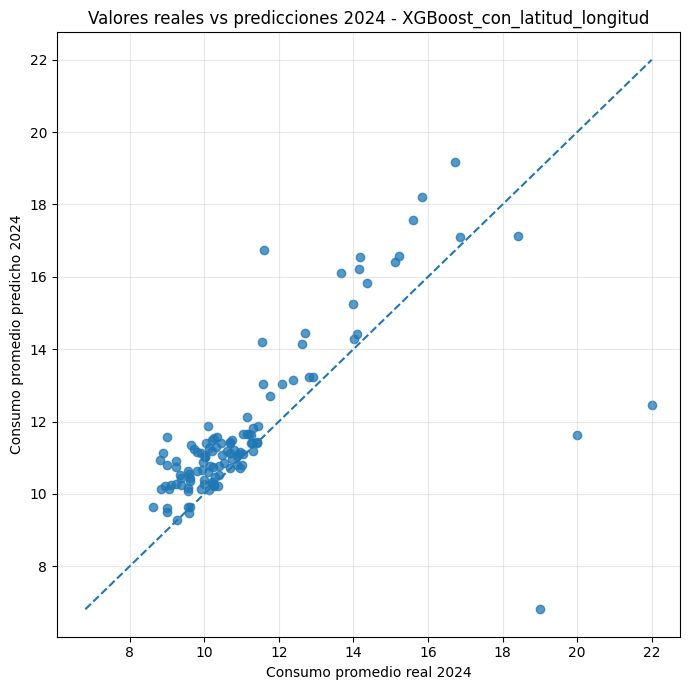

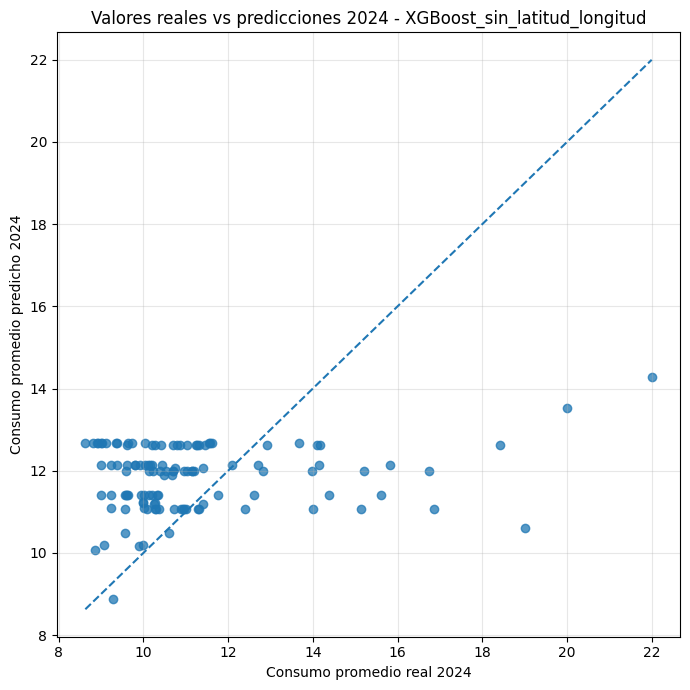

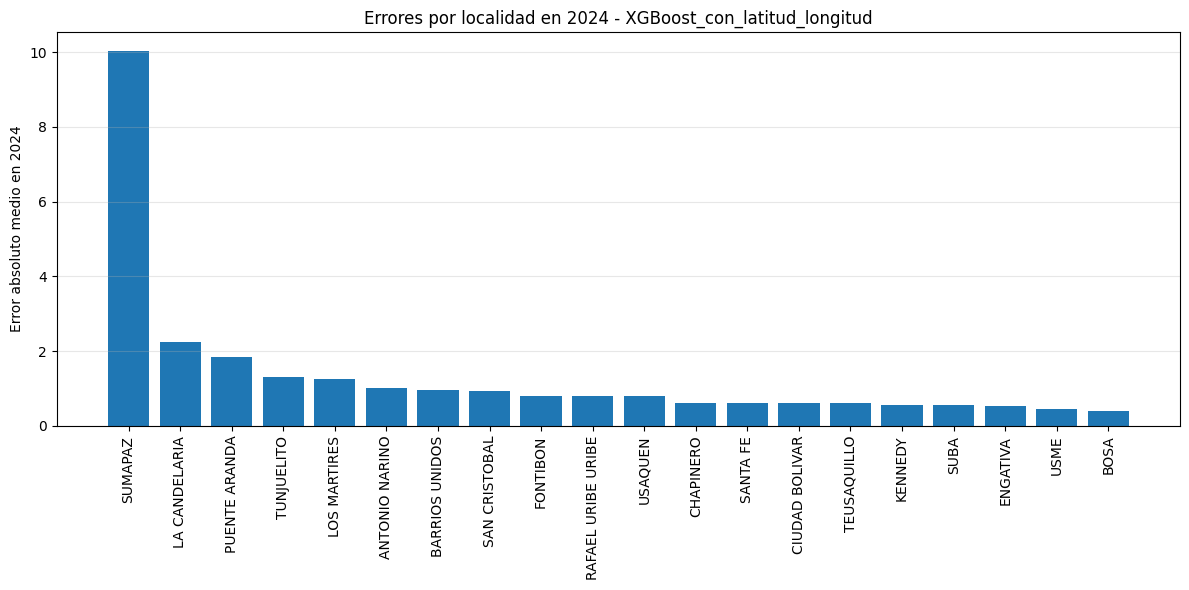

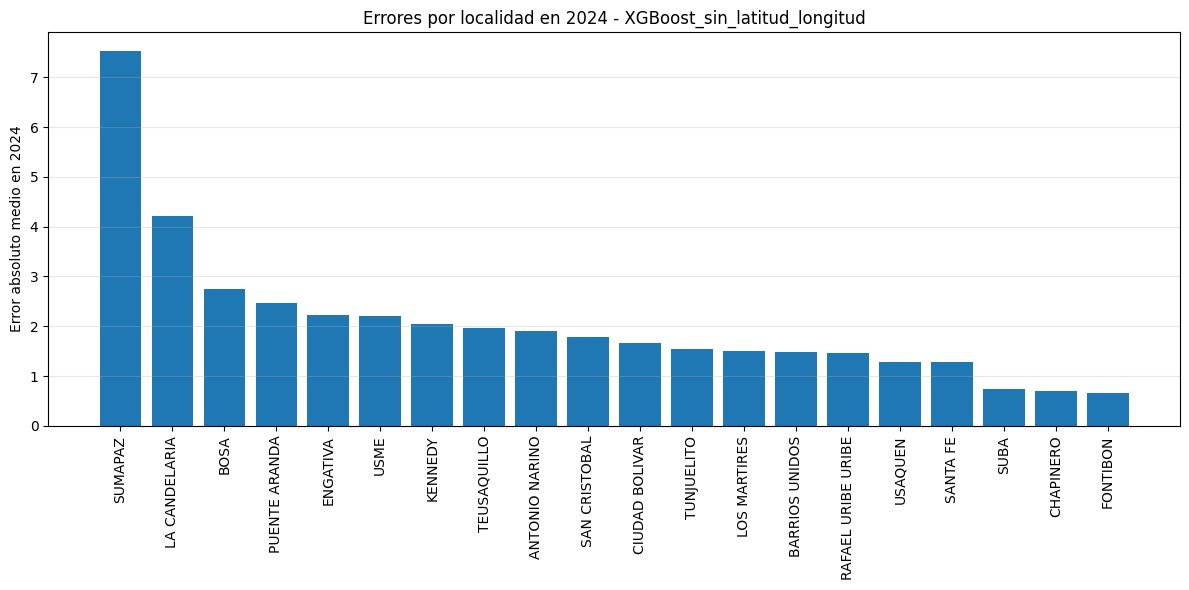

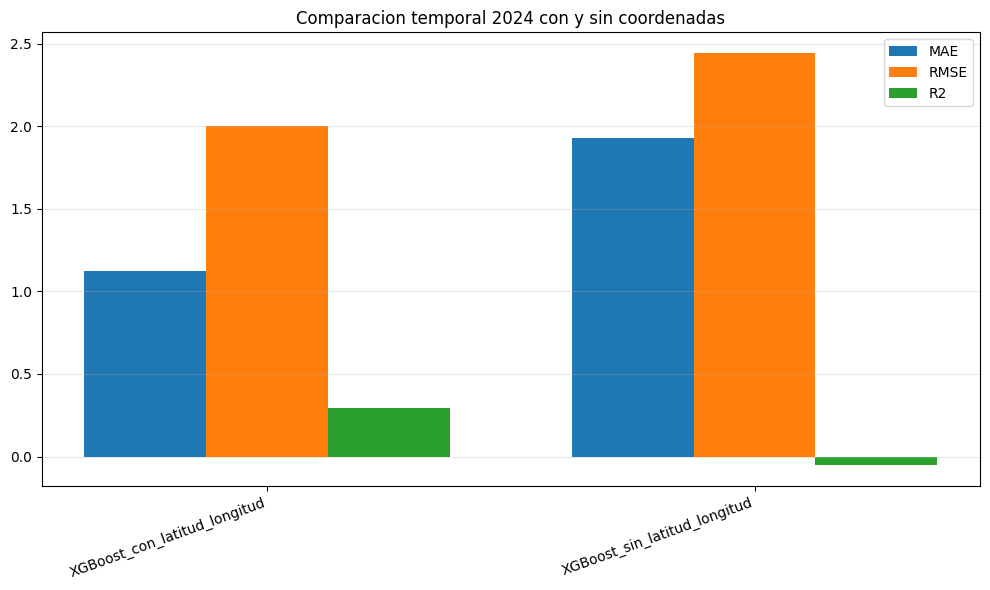

In [7]:
comparacion_temporal_con_sin_espaciales = resultados_validacion_temporal[
    resultados_validacion_temporal["conjunto"].isin(["validacion_2023", "prueba_2024"])
].copy()
comparacion_temporal_con_sin_espaciales.to_csv("comparacion_temporal_con_sin_espaciales_v8.csv", index=False, encoding="utf-8-sig")

display(comparacion_temporal_con_sin_espaciales)

# Grafica: valores reales vs predicciones en 2024.
for modelo in predicciones_temporales_2024["modelo"].unique():
    sub = predicciones_temporales_2024[predicciones_temporales_2024["modelo"] == modelo]
    plt.figure(figsize=(7, 7))
    plt.scatter(sub["valor_real"], sub["prediccion"], alpha=0.75)
    min_v = min(sub["valor_real"].min(), sub["prediccion"].min())
    max_v = max(sub["valor_real"].max(), sub["prediccion"].max())
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    plt.xlabel("Consumo promedio real 2024")
    plt.ylabel("Consumo promedio predicho 2024")
    plt.title(f"Valores reales vs predicciones 2024 - {modelo}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Grafica: error absoluto promedio por localidad.
errores_localidad = (
    predicciones_temporales_2024
    .groupby(["modelo", "localidad"], as_index=False)["error_absoluto"].mean()
    .sort_values(["modelo", "error_absoluto"], ascending=[True, False])
)
for modelo in errores_localidad["modelo"].unique():
    sub = errores_localidad[errores_localidad["modelo"] == modelo]
    plt.figure(figsize=(12, 6))
    plt.bar(sub["localidad"], sub["error_absoluto"])
    plt.xticks(rotation=90)
    plt.ylabel("Error absoluto medio en 2024")
    plt.title(f"Errores por localidad en 2024 - {modelo}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Grafica: comparacion temporal con y sin coordenadas.
test_comp = comparacion_temporal_con_sin_espaciales[comparacion_temporal_con_sin_espaciales["conjunto"] == "prueba_2024"].copy()
x = np.arange(len(test_comp))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, test_comp["MAE"], width=width, label="MAE")
plt.bar(x, test_comp["RMSE"], width=width, label="RMSE")
plt.bar(x + width, test_comp["R2"], width=width, label="R2")
plt.xticks(x, test_comp["modelo"], rotation=20, ha="right")
plt.title("Comparacion temporal 2024 con y sin coordenadas")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Validacion temporal de origen movil con ventana expansiva


In [8]:
ROLLING_CUTS = [
    {"iteracion": 1, "train_years": [2020], "test_year": 2021},
    {"iteracion": 2, "train_years": [2020, 2021], "test_year": 2022},
    {"iteracion": 3, "train_years": [2020, 2021, 2022], "test_year": 2023},
    {"iteracion": 4, "train_years": [2020, 2021, 2022, 2023], "test_year": 2024},
]

def rolling_origin_xgb(include_spatial):
    model_label = "XGBoost_con_latitud_longitud" if include_spatial else "XGBoost_sin_latitud_longitud"
    X, y_log, meta, dropped = build_design_matrix(df_raw, include_spatial=include_spatial)
    rows = []
    for cut in ROLLING_CUTS:
        train_mask = meta[YEAR_COL].isin(cut["train_years"])
        test_mask = meta[YEAR_COL].eq(cut["test_year"])
        assert meta.loc[train_mask, YEAR_COL].max() < meta.loc[test_mask, YEAR_COL].min()
        assert set(meta.loc[train_mask, "_row_id"]).isdisjoint(set(meta.loc[test_mask, "_row_id"]))

        X_train_raw, X_test_raw = X.loc[train_mask].copy(), X.loc[test_mask].copy()
        y_train, y_test = y_log.loc[train_mask].copy(), y_log.loc[test_mask].copy()
        (X_train, X_test), imputer = impute_from_train(X_train_raw, X_test_raw)

        model = make_xgb_model(XGB_V5_FINAL_PARAMS)
        model.fit(X_train, y_train.values, verbose=False)
        pred_test = model.predict(X_test)
        met = metrics_original_scale(y_test, pred_test)
        rows.append({
            "modelo": model_label,
            "iteracion": cut["iteracion"],
            "entrenamiento": year_label(cut["train_years"]),
            "prueba": int(cut["test_year"]),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "n_features": X.shape[1],
            "configuracion": "XGB_V5_FINAL_PARAMS fija",
            **met,
        })
    return pd.DataFrame(rows)


resultados_rolling_origin = pd.concat([
    rolling_origin_xgb(include_spatial=True),
    rolling_origin_xgb(include_spatial=False),
], ignore_index=True)
resultados_rolling_origin.to_csv("resultados_rolling_origin_v8.csv", index=False, encoding="utf-8-sig")

resumen_rolling_origin = (
    resultados_rolling_origin
    .groupby("modelo")[["MAE", "RMSE", "R2"]]
    .agg(["mean", "median", "std"])
)
resumen_rolling_origin.columns = ["_".join(col).strip() for col in resumen_rolling_origin.columns.to_flat_index()]
resumen_rolling_origin = resumen_rolling_origin.reset_index()
resumen_rolling_origin.to_csv("resumen_rolling_origin_v8.csv", index=False, encoding="utf-8-sig")

print("Resultados individuales de origen movil:")
display(resultados_rolling_origin)
print("Resumen de origen movil:")
display(resumen_rolling_origin)


Resultados individuales de origen movil:


,modelo,iteracion,entrenamiento,prueba,n_train,n_test,n_features,configuracion,MAE,RMSE,R2
0,XGBoost_con_latitud_longitud,1,2020,2021,120,120,24,XGB_V5_FINAL_PARAMS fija,0.793840,2.371890,0.638999
1,XGBoost_con_latitud_longitud,2,2020-2021,2022,240,119,24,XGB_V5_FINAL_PARAMS fija,0.866927,1.498872,0.754797
2,XGBoost_con_latitud_longitud,3,2020-2022,2023,359,120,24,XGB_V5_FINAL_PARAMS fija,0.990037,2.591766,-0.285439
3,XGBoost_con_latitud_longitud,4,2020-2023,2024,479,117,24,XGB_V5_FINAL_PARAMS fija,1.140174,1.951257,0.327940
4,XGBoost_sin_latitud_longitud,1,2020,2021,120,120,22,XGB_V5_FINAL_PARAMS fija,2.097087,3.759466,0.093075
5,XGBoost_sin_latitud_longitud,2,2020-2021,2022,240,119,22,XGB_V5_FINAL_PARAMS fija,2.046796,2.710789,0.197973
6,XGBoost_sin_latitud_longitud,3,2020-2022,2023,359,120,22,XGB_V5_FINAL_PARAMS fija,2.337827,3.504891,-1.350763
7,XGBoost_sin_latitud_longitud,4,2020-2023,2024,479,117,22,XGB_V5_FINAL_PARAMS fija,1.998990,2.507585,-0.109918


Resumen de origen movil:


,modelo,MAE_mean,MAE_median,MAE_std,RMSE_mean,RMSE_median,RMSE_std,R2_mean,R2_median,R2_std
0,XGBoost_con_latitud_longitud,0.947744,0.928482,0.151697,2.103446,2.161574,0.482767,0.359074,0.483469,0.465947
1,XGBoost_sin_latitud_longitud,2.120175,2.071942,0.150528,3.120683,3.107840,0.605409,-0.292408,-0.008421,0.717051


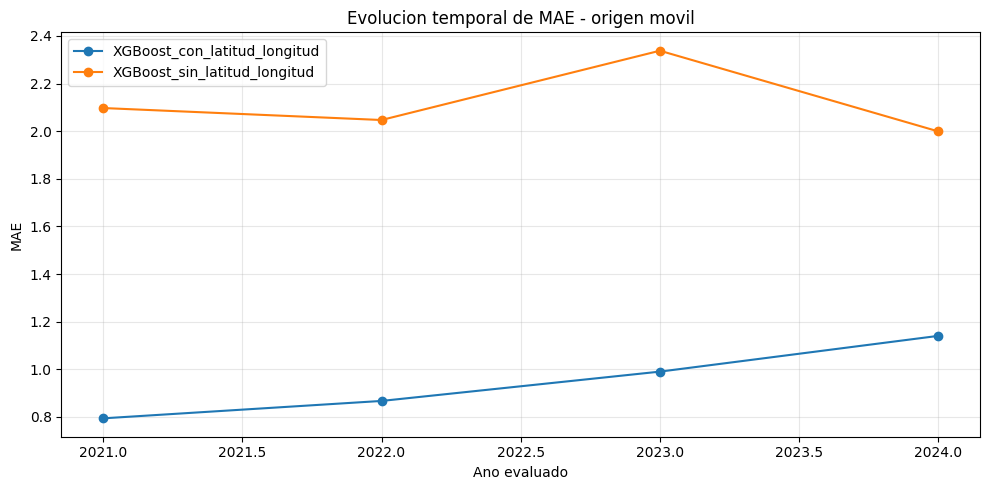

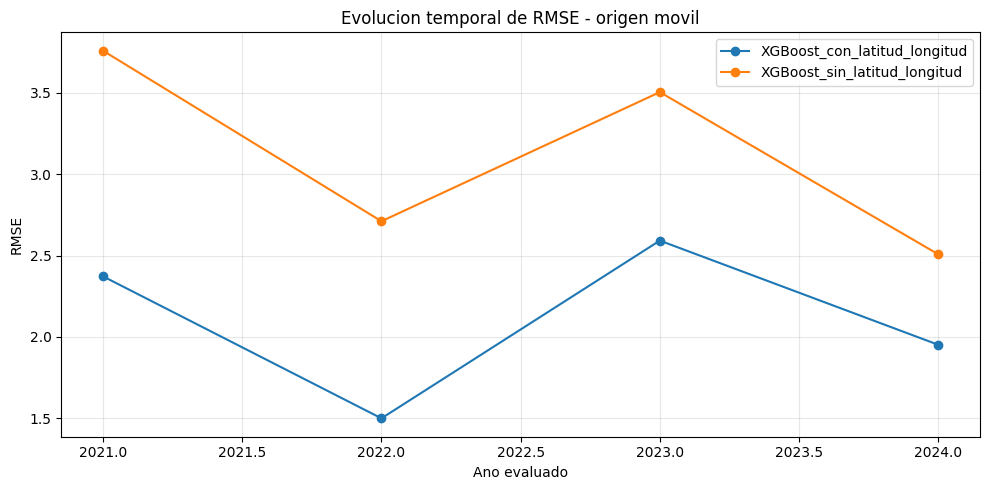

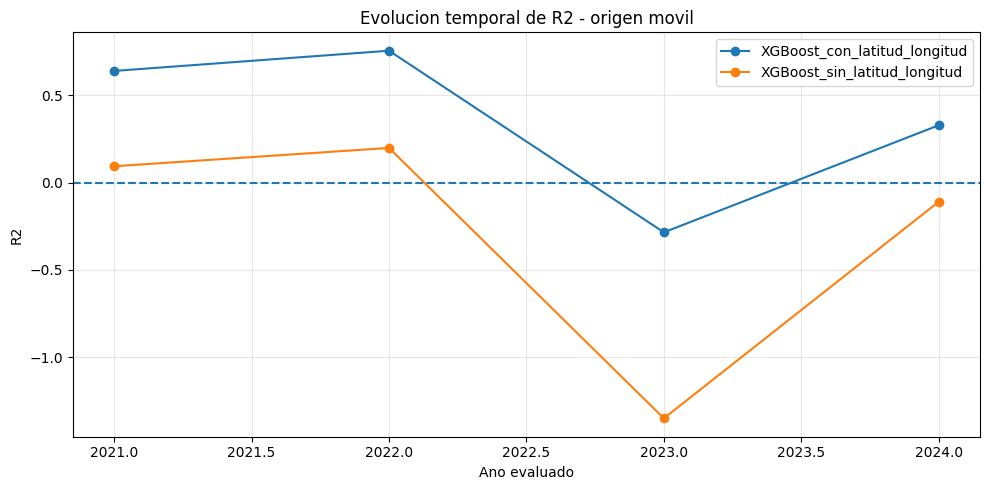

In [9]:
for metric in ["MAE", "RMSE"]:
    plt.figure(figsize=(10, 5))
    for modelo in resultados_rolling_origin["modelo"].unique():
        sub = resultados_rolling_origin[resultados_rolling_origin["modelo"] == modelo]
        plt.plot(sub["prueba"], sub[metric], marker="o", label=modelo)
    plt.xlabel("Ano evaluado")
    plt.ylabel(metric)
    plt.title(f"Evolucion temporal de {metric} - origen movil")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
for modelo in resultados_rolling_origin["modelo"].unique():
    sub = resultados_rolling_origin[resultados_rolling_origin["modelo"] == modelo]
    plt.plot(sub["prueba"], sub["R2"], marker="o", label=modelo)
plt.axhline(0, linestyle="--")
plt.xlabel("Ano evaluado")
plt.ylabel("R2")
plt.title("Evolucion temporal de R2 - origen movil")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Comparacion conceptual con particion aleatoria y validacion espacial LOLO


,esquema,modelo,tipo_resultado,MAE,RMSE,R2,capacidad_evaluada,fuente
0,particion_aleatoria_v7,con_latitud_longitud,test_aleatorio,0.423633,0.746701,0.890315,interpolacion entre registros de localidades y...,comparacion_xgboost_con_sin_espaciales.csv
1,particion_aleatoria_v7,sin_latitud_longitud,test_aleatorio,1.531498,2.108955,0.125043,interpolacion entre registros de localidades y...,comparacion_xgboost_con_sin_espaciales.csv
2,division_temporal_v8,XGBoost_con_latitud_longitud,prueba_2024,1.121197,2.000640,0.293491,generalizacion hacia un ano posterior con cova...,resultados_validacion_temporal_v8.csv
3,division_temporal_v8,XGBoost_sin_latitud_longitud,prueba_2024,1.931455,2.443260,-0.053704,generalizacion hacia un ano posterior con cova...,resultados_validacion_temporal_v8.csv
4,origen_movil_v8,XGBoost_con_latitud_longitud,promedio_retrospectivo,0.947744,2.103446,0.359074,estabilidad retrospectiva al avanzar en el tiempo,resumen_rolling_origin_v8.csv
5,origen_movil_v8,XGBoost_sin_latitud_longitud,promedio_retrospectivo,2.120175,3.120683,-0.292408,estabilidad retrospectiva al avanzar en el tiempo,resumen_rolling_origin_v8.csv
6,LOLO_v6_todas_las_localidades,XGBoost_LOLO,media_por_localidad,2.278013,2.512943,-48.581158,generalizacion hacia localidades no observadas,resultados_leave_one_localidad_out.csv
7,LOLO_v6_sin_sumapaz,XGBoost_LOLO_sin_sumapaz,media_por_localidad,1.581313,1.673359,-11.651633,generalizacion espacial excluyendo Sumapaz com...,resultados_leave_one_localidad_out_sin_sumapaz...


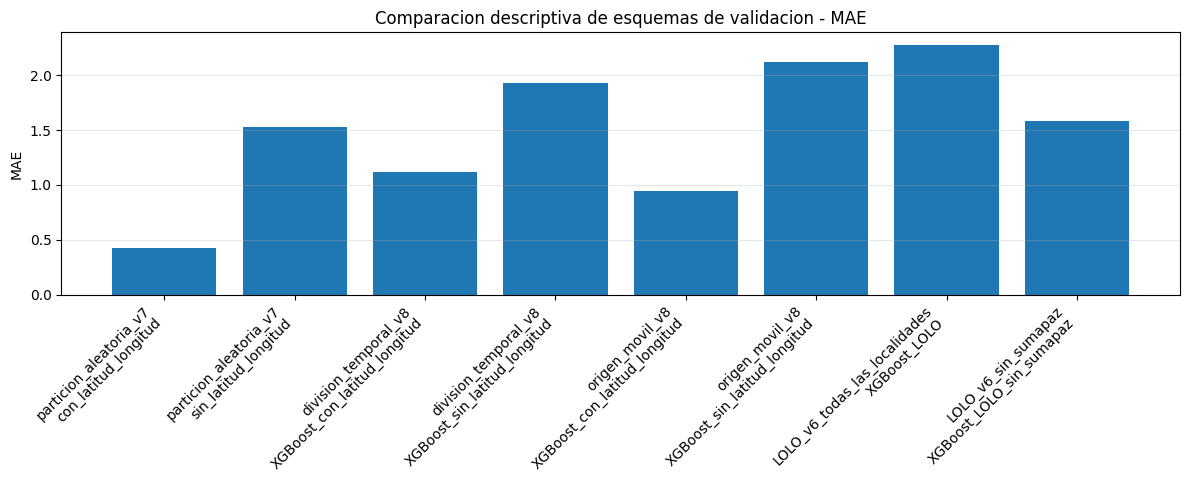

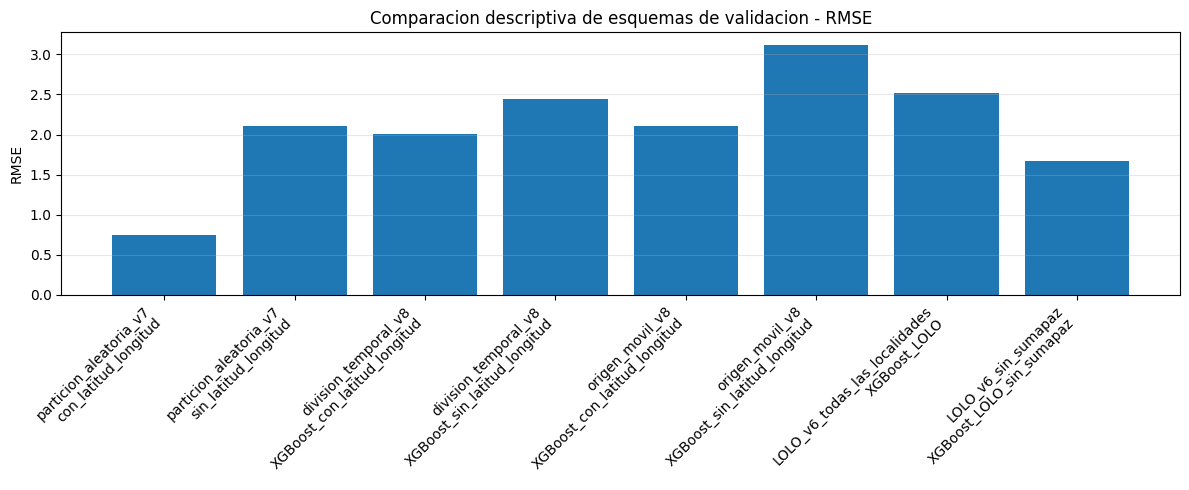

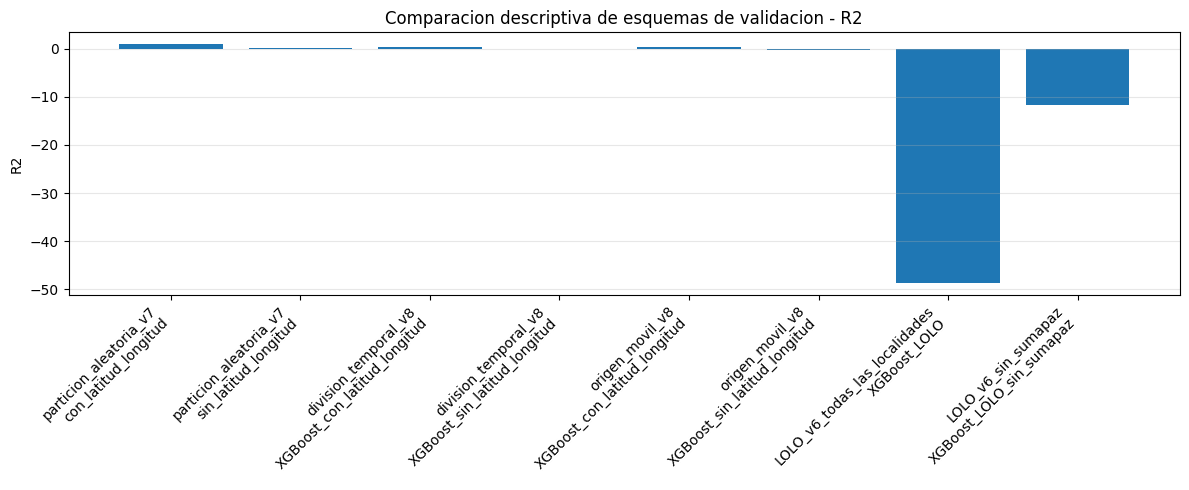

In [10]:
rows_comparacion = []

random_path = Path("comparacion_xgboost_con_sin_espaciales.csv")
if random_path.exists():
    random_df = pd.read_csv(random_path)
    random_test = random_df[random_df["conjunto"] == "test"].copy()
    for _, row in random_test.iterrows():
        rows_comparacion.append({
            "esquema": "particion_aleatoria_v7",
            "modelo": row["modelo"],
            "tipo_resultado": "test_aleatorio",
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "R2": row["R2"],
            "capacidad_evaluada": "interpolacion entre registros de localidades y periodos mezclados",
            "fuente": str(random_path),
        })

temporal_test = resultados_validacion_temporal[
    (resultados_validacion_temporal["etapa"] == "modelo_final") &
    (resultados_validacion_temporal["conjunto"] == "prueba_2024")
].copy()
for _, row in temporal_test.iterrows():
    rows_comparacion.append({
        "esquema": "division_temporal_v8",
        "modelo": row["modelo"],
        "tipo_resultado": "prueba_2024",
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2": row["R2"],
        "capacidad_evaluada": "generalizacion hacia un ano posterior con covariables contemporaneas",
        "fuente": "resultados_validacion_temporal_v8.csv",
    })

for _, row in resumen_rolling_origin.iterrows():
    rows_comparacion.append({
        "esquema": "origen_movil_v8",
        "modelo": row["modelo"],
        "tipo_resultado": "promedio_retrospectivo",
        "MAE": row["MAE_mean"],
        "RMSE": row["RMSE_mean"],
        "R2": row["R2_mean"],
        "capacidad_evaluada": "estabilidad retrospectiva al avanzar en el tiempo",
        "fuente": "resumen_rolling_origin_v8.csv",
    })

lolo_path = Path("resultados_leave_one_localidad_out.csv")
lolo_sin_sumapaz_path = Path("resultados_leave_one_localidad_out_sin_sumapaz.csv")
if lolo_path.exists():
    lolo = pd.read_csv(lolo_path)
    lolo_mean = lolo[["MAE_test", "RMSE_test", "R2_test"]].mean()
    rows_comparacion.append({
        "esquema": "LOLO_v6_todas_las_localidades",
        "modelo": "XGBoost_LOLO",
        "tipo_resultado": "media_por_localidad",
        "MAE": lolo_mean["MAE_test"],
        "RMSE": lolo_mean["RMSE_test"],
        "R2": lolo_mean["R2_test"],
        "capacidad_evaluada": "generalizacion hacia localidades no observadas",
        "fuente": str(lolo_path),
    })
else:
    lolo = None

if lolo_sin_sumapaz_path.exists():
    lolo_sin_sumapaz = pd.read_csv(lolo_sin_sumapaz_path)
    lolo_sin_sumapaz_mean = lolo_sin_sumapaz[["MAE_test", "RMSE_test", "R2_test"]].mean()
    rows_comparacion.append({
        "esquema": "LOLO_v6_sin_sumapaz",
        "modelo": "XGBoost_LOLO_sin_sumapaz",
        "tipo_resultado": "media_por_localidad",
        "MAE": lolo_sin_sumapaz_mean["MAE_test"],
        "RMSE": lolo_sin_sumapaz_mean["RMSE_test"],
        "R2": lolo_sin_sumapaz_mean["R2_test"],
        "capacidad_evaluada": "generalizacion espacial excluyendo Sumapaz como caso atipico",
        "fuente": str(lolo_sin_sumapaz_path),
    })
else:
    lolo_sin_sumapaz = None

comparacion_esquemas_validacion = pd.DataFrame(rows_comparacion)
comparacion_esquemas_validacion.to_csv("comparacion_esquemas_validacion_v8.csv", index=False, encoding="utf-8-sig")
display(comparacion_esquemas_validacion)

plot_df = comparacion_esquemas_validacion.copy()
plot_df["etiqueta"] = plot_df["esquema"] + "\n" + plot_df["modelo"].astype(str)
for metric in ["MAE", "RMSE", "R2"]:
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["etiqueta"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"Comparacion descriptiva de esquemas de validacion - {metric}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Estado de la red neuronal en el experimento temporal


In [11]:
if TORCH_AVAILABLE:
    print(
        "PyTorch se pudo importar, pero la evaluacion de la red neuronal no se ejecuta en v8 "
        "porque los notebooks v5-v7 no contienen una arquitectura final nueva de red neuronal. "
        "Las arquitecturas previas pertenecen a v1-v2 y no se reutilizan aqui para evitar mezclar "
        "decisiones metodologicas no documentadas dentro de v5-v7."
    )
else:
    print("La red neuronal no fue evaluada en v8 por una dificultad tecnica verificable.")
    print("Error de importacion de PyTorch:")
    print(TORCH_IMPORT_ERROR)
    print(
        "No se reutilizaron pesos previos ni se reconstruyeron metricas manualmente. "
        "Por tanto, los resultados temporales de v8 se limitan a XGBoost."
    )


PyTorch se pudo importar, pero la evaluacion de la red neuronal no se ejecuta en v8 porque los notebooks v5-v7 no contienen una arquitectura final nueva de red neuronal. Las arquitecturas previas pertenecen a v1-v2 y no se reutilizan aqui para evitar mezclar decisiones metodologicas no documentadas dentro de v5-v7.


## 10. Sintesis academica y texto propuesto para la tesis


In [12]:
val_2023 = resultados_validacion_temporal[
    (resultados_validacion_temporal["etapa"] == "seleccion_temporal") &
    (resultados_validacion_temporal["conjunto"] == "validacion_2023")
].copy()
test_2024 = resultados_validacion_temporal[
    (resultados_validacion_temporal["etapa"] == "modelo_final") &
    (resultados_validacion_temporal["conjunto"] == "prueba_2024")
].copy()

best_2024 = test_2024.sort_values(["RMSE", "MAE"], ascending=[True, True]).iloc[0]
worst_note = ""
if (test_2024["R2"] < 0).any() or (resultados_rolling_origin["R2"] < 0).any():
    worst_note = (
        " En los escenarios donde R2 es negativo, el resultado indica que el modelo obtiene un desempeno inferior "
        "al predictor de referencia basado en la media del conjunto evaluado; por ello, esos valores no deben "
        "interpretarse como capacidad de generalizacion satisfactoria."
    )

temporal_con = test_2024[test_2024["modelo"] == "XGBoost_con_latitud_longitud"].iloc[0]
temporal_sin = test_2024[test_2024["modelo"] == "XGBoost_sin_latitud_longitud"].iloc[0]

rolling_con = resumen_rolling_origin[resumen_rolling_origin["modelo"] == "XGBoost_con_latitud_longitud"].iloc[0]
rolling_sin = resumen_rolling_origin[resumen_rolling_origin["modelo"] == "XGBoost_sin_latitud_longitud"].iloc[0]

random_con = comparacion_esquemas_validacion[
    (comparacion_esquemas_validacion["esquema"] == "particion_aleatoria_v7") &
    (comparacion_esquemas_validacion["modelo"] == "con_latitud_longitud")
]
if not random_con.empty:
    random_con = random_con.iloc[0]

lolo_all = comparacion_esquemas_validacion[comparacion_esquemas_validacion["esquema"] == "LOLO_v6_todas_las_localidades"]
lolo_sin = comparacion_esquemas_validacion[comparacion_esquemas_validacion["esquema"] == "LOLO_v6_sin_sumapaz"]

def simple_markdown_table(df, columns):
    tmp = df[columns].copy()
    for col in tmp.columns:
        if pd.api.types.is_numeric_dtype(tmp[col]):
            tmp[col] = tmp[col].map(lambda x: f"{x:.4f}")
    header = "| " + " | ".join(tmp.columns) + " |"
    sep = "| " + " | ".join(["---"] * len(tmp.columns)) + " |"
    body = [
        "| " + " | ".join(str(value) for value in row) + " |"
        for row in tmp.to_numpy()
    ]
    return "\n".join([header, sep] + body)

val_table_md = simple_markdown_table(val_2023, ["modelo", "MAE", "RMSE", "R2"])
test_table_md = simple_markdown_table(test_2024, ["modelo", "MAE", "RMSE", "R2"])

texto = f'''
### Sintesis de resultados v8

La division temporal principal separo el panel localidad-tiempo en entrenamiento 2020-2022, validacion 2023 y prueba final 2024. La seleccion de hiperparametros se realizo exclusivamente con 2023, sin utilizar registros de 2024. Una vez seleccionada la configuracion, el modelo final se reentreno con 2020-2023 y se evaluo una unica vez sobre 2024.

En la validacion 2023, los resultados fueron:

{val_table_md}

En la prueba final 2024, los resultados fueron:

{test_table_md}

El mejor desempeno temporal final correspondio a {best_2024["modelo"]}, con MAE={best_2024["MAE"]:.4f}, RMSE={best_2024["RMSE"]:.4f} y R2={best_2024["R2"]:.4f}. La comparacion con y sin coordenadas muestra que latitud y longitud {'mantuvieron' if temporal_con["RMSE"] < temporal_sin["RMSE"] else 'no mantuvieron'} utilidad predictiva en la evaluacion de 2024. Con coordenadas, el modelo obtuvo MAE={temporal_con["MAE"]:.4f}, RMSE={temporal_con["RMSE"]:.4f} y R2={temporal_con["R2"]:.4f}; sin coordenadas, obtuvo MAE={temporal_sin["MAE"]:.4f}, RMSE={temporal_sin["RMSE"]:.4f} y R2={temporal_sin["R2"]:.4f}.

La validacion de origen movil se interpreto como un analisis retrospectivo de estabilidad temporal, no como prueba confirmatoria equivalente a la evaluacion final sobre 2024. En promedio, el esquema movil con coordenadas obtuvo MAE={rolling_con["MAE_mean"]:.4f}, RMSE={rolling_con["RMSE_mean"]:.4f} y R2={rolling_con["R2_mean"]:.4f}; sin coordenadas obtuvo MAE={rolling_sin["MAE_mean"]:.4f}, RMSE={rolling_sin["RMSE_mean"]:.4f} y R2={rolling_sin["R2_mean"]:.4f}.{worst_note}

La comparacion con la particion aleatoria de v7 y con LOLO de v6 muestra que los esquemas no evaluan la misma capacidad. La particion aleatoria mide principalmente interpolacion entre registros mezclados de localidades y anos observados. La division temporal evalua la transferencia hacia un ano posterior, bajo el supuesto de contar con covariables contemporaneas del periodo objetivo. El origen movil analiza la estabilidad al avanzar cronologicamente. LOLO evalua una condicion mas exigente: generalizacion hacia localidades completamente no observadas. Por tanto, sus metricas deben presentarse por separado y no promediarse como si fueran equivalentes.

Texto propuesto para la metodologia: "Con el fin de controlar la posible fuga de informacion temporal derivada de la estructura de panel localidad-tiempo, se incorporo un experimento adicional de validacion cronologica. Los registros se ordenaron por ano, bimestre y localidad, y se definio una particion con entrenamiento en 2020-2022, validacion en 2023 y prueba final en 2024. La imputacion se ajusto exclusivamente con los datos de entrenamiento de cada division y la variable objetivo se transformo mediante log1p durante el entrenamiento, calculando MAE, RMSE y R2 en la escala original mediante expm1."

Texto propuesto para construccion de modelos: "El modelo XGBoost fue evaluado en dos variantes comparables: una con latitud y longitud, y otra sin estas coordenadas. La seleccion de hiperparametros se realizo con el ano 2023 y la evaluacion final se efectuo una sola vez sobre 2024, despues de reentrenar el modelo con los registros 2020-2023. Esta estrategia evito utilizar informacion de 2024 para seleccionar variables, ajustar hiperparametros o tomar decisiones de modelado."

Texto propuesto para validacion: "Adicionalmente, se implemento una validacion de origen movil con ventana expansiva, entrenando sucesivamente con 2020 para evaluar 2021, con 2020-2021 para evaluar 2022, con 2020-2022 para evaluar 2023 y con 2020-2023 para evaluar 2024. Este procedimiento permitio analizar la estabilidad temporal del modelo y diferenciar la generalizacion cronologica de la generalizacion espacial evaluada previamente mediante Leave-One-Localidad-Out."

Texto propuesto para discusion: "Los resultados evidencian que el desempeno obtenido bajo particion aleatoria no debe interpretarse automaticamente como capacidad de prediccion futura estricta. La evaluacion temporal introduce una condicion mas cercana al uso secuencial del panel y permite observar si los patrones aprendidos en anos previos se conservan en anos posteriores. Asimismo, la comparacion con LOLO muestra que generalizar en el tiempo dentro de localidades observadas y generalizar hacia localidades no observadas son problemas metodologicamente distintos."

Texto propuesto para conclusiones: "El experimento temporal complementario fortalece la validez metodologica de la investigacion al separar la evaluacion aleatoria, temporal y espacial. El alcance predictivo del modelo debe entenderse dentro de las condiciones evaluadas: estimacion de consumo promedio para localidades observadas, con covariables climaticas contemporaneas disponibles y bajo validaciones que muestran desempenos distintos segun el tipo de generalizacion exigida."

Texto propuesto para limitaciones: "Una limitacion relevante es que las variables climaticas utilizadas corresponden a la misma unidad ano-bimestre-localidad del consumo observado. Por ello, el experimento temporal evalua una estimacion para un periodo posterior con covariables contemporaneas conocidas, pero no necesariamente un pronostico anticipado antes de conocer las condiciones climaticas del bimestre objetivo. Ademas, los resultados LOLO indican que la generalizacion hacia localidades no observadas sigue siendo limitada y requiere validaciones adicionales antes de cualquier uso operativo territorial."
'''

display(Markdown(texto))



### Sintesis de resultados v8

La division temporal principal separo el panel localidad-tiempo en entrenamiento 2020-2022, validacion 2023 y prueba final 2024. La seleccion de hiperparametros se realizo exclusivamente con 2023, sin utilizar registros de 2024. Una vez seleccionada la configuracion, el modelo final se reentreno con 2020-2023 y se evaluo una unica vez sobre 2024.

En la validacion 2023, los resultados fueron:

| modelo | MAE | RMSE | R2 |
| --- | --- | --- | --- |
| XGBoost_con_latitud_longitud | 0.8764 | 2.3999 | -0.1022 |
| XGBoost_sin_latitud_longitud | 2.0580 | 3.1456 | -0.8935 |

En la prueba final 2024, los resultados fueron:

| modelo | MAE | RMSE | R2 |
| --- | --- | --- | --- |
| XGBoost_con_latitud_longitud | 1.1212 | 2.0006 | 0.2935 |
| XGBoost_sin_latitud_longitud | 1.9315 | 2.4433 | -0.0537 |

El mejor desempeno temporal final correspondio a XGBoost_con_latitud_longitud, con MAE=1.1212, RMSE=2.0006 y R2=0.2935. La comparacion con y sin coordenadas muestra que latitud y longitud mantuvieron utilidad predictiva en la evaluacion de 2024. Con coordenadas, el modelo obtuvo MAE=1.1212, RMSE=2.0006 y R2=0.2935; sin coordenadas, obtuvo MAE=1.9315, RMSE=2.4433 y R2=-0.0537.

La validacion de origen movil se interpreto como un analisis retrospectivo de estabilidad temporal, no como prueba confirmatoria equivalente a la evaluacion final sobre 2024. En promedio, el esquema movil con coordenadas obtuvo MAE=0.9477, RMSE=2.1034 y R2=0.3591; sin coordenadas obtuvo MAE=2.1202, RMSE=3.1207 y R2=-0.2924. En los escenarios donde R2 es negativo, el resultado indica que el modelo obtiene un desempeno inferior al predictor de referencia basado en la media del conjunto evaluado; por ello, esos valores no deben interpretarse como capacidad de generalizacion satisfactoria.

La comparacion con la particion aleatoria de v7 y con LOLO de v6 muestra que los esquemas no evaluan la misma capacidad. La particion aleatoria mide principalmente interpolacion entre registros mezclados de localidades y anos observados. La division temporal evalua la transferencia hacia un ano posterior, bajo el supuesto de contar con covariables contemporaneas del periodo objetivo. El origen movil analiza la estabilidad al avanzar cronologicamente. LOLO evalua una condicion mas exigente: generalizacion hacia localidades completamente no observadas. Por tanto, sus metricas deben presentarse por separado y no promediarse como si fueran equivalentes.

Texto propuesto para la metodologia: "Con el fin de controlar la posible fuga de informacion temporal derivada de la estructura de panel localidad-tiempo, se incorporo un experimento adicional de validacion cronologica. Los registros se ordenaron por ano, bimestre y localidad, y se definio una particion con entrenamiento en 2020-2022, validacion en 2023 y prueba final en 2024. La imputacion se ajusto exclusivamente con los datos de entrenamiento de cada division y la variable objetivo se transformo mediante log1p durante el entrenamiento, calculando MAE, RMSE y R2 en la escala original mediante expm1."

Texto propuesto para construccion de modelos: "El modelo XGBoost fue evaluado en dos variantes comparables: una con latitud y longitud, y otra sin estas coordenadas. La seleccion de hiperparametros se realizo con el ano 2023 y la evaluacion final se efectuo una sola vez sobre 2024, despues de reentrenar el modelo con los registros 2020-2023. Esta estrategia evito utilizar informacion de 2024 para seleccionar variables, ajustar hiperparametros o tomar decisiones de modelado."

Texto propuesto para validacion: "Adicionalmente, se implemento una validacion de origen movil con ventana expansiva, entrenando sucesivamente con 2020 para evaluar 2021, con 2020-2021 para evaluar 2022, con 2020-2022 para evaluar 2023 y con 2020-2023 para evaluar 2024. Este procedimiento permitio analizar la estabilidad temporal del modelo y diferenciar la generalizacion cronologica de la generalizacion espacial evaluada previamente mediante Leave-One-Localidad-Out."

Texto propuesto para discusion: "Los resultados evidencian que el desempeno obtenido bajo particion aleatoria no debe interpretarse automaticamente como capacidad de prediccion futura estricta. La evaluacion temporal introduce una condicion mas cercana al uso secuencial del panel y permite observar si los patrones aprendidos en anos previos se conservan en anos posteriores. Asimismo, la comparacion con LOLO muestra que generalizar en el tiempo dentro de localidades observadas y generalizar hacia localidades no observadas son problemas metodologicamente distintos."

Texto propuesto para conclusiones: "El experimento temporal complementario fortalece la validez metodologica de la investigacion al separar la evaluacion aleatoria, temporal y espacial. El alcance predictivo del modelo debe entenderse dentro de las condiciones evaluadas: estimacion de consumo promedio para localidades observadas, con covariables climaticas contemporaneas disponibles y bajo validaciones que muestran desempenos distintos segun el tipo de generalizacion exigida."

Texto propuesto para limitaciones: "Una limitacion relevante es que las variables climaticas utilizadas corresponden a la misma unidad ano-bimestre-localidad del consumo observado. Por ello, el experimento temporal evalua una estimacion para un periodo posterior con covariables contemporaneas conocidas, pero no necesariamente un pronostico anticipado antes de conocer las condiciones climaticas del bimestre objetivo. Ademas, los resultados LOLO indican que la generalizacion hacia localidades no observadas sigue siendo limitada y requiere validaciones adicionales antes de cualquier uso operativo territorial."


## 11. Verificacion final del experimento v8


In [13]:
required_csvs = [
    "resultados_validacion_temporal_v8.csv",
    "resultados_rolling_origin_v8.csv",
    "resumen_rolling_origin_v8.csv",
    "comparacion_esquemas_validacion_v8.csv",
    "predicciones_temporales_2024_v8.csv",
    "comparacion_temporal_con_sin_espaciales_v8.csv",
]

print("Archivos CSV requeridos:")
for path in required_csvs:
    exists = Path(path).exists()
    print(f" - {path}: {'OK' if exists else 'NO ENCONTRADO'}")
    assert exists

assert set(predicciones_temporales_2024["ano"].unique()) == {2024}
assert not resultados_tuning_temporal.columns.astype(str).str.contains("2024").any()
assert resultados_validacion_temporal["MAE"].notna().all()
assert resultados_validacion_temporal["RMSE"].notna().all()
assert resultados_validacion_temporal["R2"].notna().all()

print("\nVerificaciones finales superadas:")
print(" - Todas las metricas se calcularon con expm1 en escala original.")
print(" - Los CSV requeridos fueron creados.")
print(" - Las predicciones finales corresponden unicamente a 2024.")
print(" - 2024 no aparece como columna de seleccion de hiperparametros.")
print(" - No se modificaron ni sobrescribieron resultados de v6 o v7 desde este notebook.")


Archivos CSV requeridos:
 - resultados_validacion_temporal_v8.csv: OK
 - resultados_rolling_origin_v8.csv: OK
 - resumen_rolling_origin_v8.csv: OK
 - comparacion_esquemas_validacion_v8.csv: OK
 - predicciones_temporales_2024_v8.csv: OK
 - comparacion_temporal_con_sin_espaciales_v8.csv: OK

Verificaciones finales superadas:
 - Todas las metricas se calcularon con expm1 en escala original.
 - Los CSV requeridos fueron creados.
 - Las predicciones finales corresponden unicamente a 2024.
 - 2024 no aparece como columna de seleccion de hiperparametros.
 - No se modificaron ni sobrescribieron resultados de v6 o v7 desde este notebook.
